# TP — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [44]:
%pip install gymnasium
%pip install "gymnasium[toy-text]"
%pip install minigrid

print("Décommentez les installations si nécessaire.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 4.3 MB/s eta 0:00:00
Décommentez les installations si nécessaire.


In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3

In [2]:
import gymnasium as gym

# Création de l'environnement
env = gym.make("Taxi-v3", render_mode="ansi")

# Affichage des métadonnées
print(f"Action Space: {env.action_space}")
print(f"Observation Space: {env.observation_space}")
print(f"Spec: {env.spec}")
print(f"Unwrapped: {env.unwrapped}")

Action Space: Discrete(6)
Observation Space: Discrete(500)
Spec: EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={'render_mode': 'ansi'}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
Unwrapped: <TaxiEnv<Taxi-v3>>


**Taxi-v3** simule un taxi devant chercher un passager et le déposer à une destination précise sur une grille de $5 \times 5$.

Cet environnement est idéal pour débuter car :
* **Simplicité** : Il possède un espace d'états fini et discret de 500 combinaisons possibles.
* **Récompense claire** : Le système de points (-1 par pas, +20 pour le succès) facilite l'évaluation des performances.
* **Analyse facile** : On peut extraire les positions exactes (taxi, passager, destination) pour créer des règles logiques simples.

## 2. Premier épisode avec actions aléatoires

In [10]:
# Initialisation
obs, info = env.reset(seed=42)
terminated = False
truncated = False
total_reward = 0
steps = 0

# Boucle de l'épisode
while not (terminated or truncated):
    action = env.action_space.sample() # Action aléatoire
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1

# Affichage des résultats
print(f"Nombre d'étapes : {steps}")
print(f"Récompense cumulée : {total_reward}")
print(f"Cause d'arrêt : {'Terminated' if terminated else 'Truncated'}")

Nombre d'étapes : 200
Récompense cumulée : -776
Cause d'arrêt : Truncated


**Analyse :** que remarquez-vous sur les performances de cette politique ?
Les performances de cette politique sont **très médiocres** pour les raisons suivantes :

* **Échec de la mission** : L'épisode s'arrête par limite de temps (**Truncated**) sans que le passager n'ait été déposé.
* **Actions pénalisantes** : Le score fortement négatif s'explique par la répétition d'actions de prise (*pickup*) ou de dépose (*dropoff*) invalides, coûtant chacune **-10 points**.
* **Errance** : Le taxi se déplace sans logique, accumulant une pénalité de **-1 point** à chaque mouvement inutile.


## 3. Politique aléatoire sur plusieurs épisodes

In [20]:
# TODO
# Écrire une fonction random_taxi_policy(obs, env)
# Lancer au moins 20 épisodes
# Stocker les résultats dans une liste ou un dictionnaire

import numpy as np

def random_taxi_policy(obs, env):
    """Retourne une action échantillonnée aléatoirement dans l'espace des actions."""
    return env.action_space.sample()

# Initialisation des paramètres
num_episodes = 20
all_results = []

for ep in range(num_episodes):
    # Reset avec une seed différente pour chaque épisode pour la reproductibilité
    obs, info = env.reset(seed=ep)
    terminated = False
    truncated = False
    total_reward = 0
    steps = 0

    while not (terminated or truncated):
        action = random_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    # Stockage des résultats dans un dictionnaire
    all_results.append({
        "episode": ep,
        "reward": total_reward,
        "steps": steps,
        "success": terminated  # True si le passager est déposé, False si le temps est écoulé
    })

In [22]:
# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès
# Extraction des données
rewards = [res["reward"] for res in all_results]
steps = [res["steps"] for res in all_results]
successes = [1 if res["success"] else 0 for res in all_results]

# Calcul des moyennes
print(f"Résultats moyens sur {num_episodes} épisodes :")
print(f"- Récompense moyenne : {np.mean(rewards):.2f}")
print(f"- Longueur moyenne   : {np.mean(steps):.2f} étapes")
print(f"- Taux de succès     : {np.mean(successes) * 100:.2f} %")

Résultats moyens sur 20 épisodes :
- Récompense moyenne : -761.80
- Longueur moyenne   : 192.40 étapes
- Taux de succès     : 10.00 %


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [25]:
# TODO
# Implémenter une politique aléatoire contrainte
def constrained_random_taxi_policy(obs, env):
    # Décoder l'état actuel pour obtenir les positions
    # taxi_row, taxi_col, passenger_location, destination
    state = list(env.unwrapped.decode(obs))
    taxi_pos = (state[0], state[1])
    pass_idx = state[2]
    dest_idx = state[3]

    # Coordonnées des 4 stations [R, G, Y, B]
    locs = [(0,0), (0,4), (4,0), (4,3)]

    # Liste de toutes les actions (0-5)
    actions = [0, 1, 2, 3, 4, 5]

    # 1. Filtrage du Pickup (action 4)
    # On ne l'autorise que si le taxi est sur la case du passager et passager non à bord
    if pass_idx < 4: # passager pas encore dans le taxi
        if taxi_pos != locs[pass_idx]:
            actions.remove(4)
    else: # passager est déjà dans le taxi
        actions.remove(4)

    # 2. Filtrage du Dropoff (action 5)
    # On ne l'autorise que si le passager est dans le taxi et à la destination
    if pass_idx == 4: # passager dans le taxi
        if taxi_pos != locs[dest_idx]:
            actions.remove(5)
    else: # passager pas dans le taxi
        actions.remove(5)

    # Choisir une action parmi celles restant
    return np.random.choice(actions)

# Test sur un épisode
obs, info = env.reset(seed=42)

In [27]:
# TODO
# Comparer la politique aléatoire simple et la politique contrainte
import numpy as np

def run_experiment(env, policy_fn, num_episodes=50):
    results = []
    for ep in range(num_episodes):
        obs, info = env.reset(seed=ep)
        terminated = False
        truncated = False
        total_reward = 0
        steps = 0

        while not (terminated or truncated):
            # Adaptation pour supporter les signatures de fonctions variées
            try:
                action = policy_fn(obs, env)
            except TypeError:
                action = policy_fn(obs, info, env, steps)

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        results.append({"reward": total_reward, "steps": steps, "success": terminated})
    return results

# Exécution des deux politiques
results_simple = run_experiment(env, random_taxi_policy)
results_constrained = run_experiment(env, constrained_random_taxi_policy)

# Calcul des moyennes
def print_stats(name, res):
    rewards = [r["reward"] for r in res]
    success_rate = np.mean([1 if r["success"] else 0 for r in res]) * 100
    print(f"{name:20} | Reward Moy: {np.mean(rewards):.2f} | Succès: {success_rate:.1f}%")

print_stats("Aléatoire Simple", results_simple)
print_stats("Aléatoire Contrainte", results_constrained)

Aléatoire Simple     | Reward Moy: -787.38 | Succès: 6.0%
Aléatoire Contrainte | Reward Moy: -189.38 | Succès: 14.0%


**Analyse :** expliquez pourquoi ce filtrage améliore ou non les résultats.

Le filtrage améliore les résultats car il élimine les **pénalités lourdes de -10 points** infligées lors d'actions `pickup` ou `dropoff` invalides. En interdisant ces erreurs, l'agent ne subit plus que le malus de déplacement de **-1 point**, ce qui augmente mécaniquement sa récompense moyenne.

Toutefois, la politique reste limitée car :
* **Absence de direction** : L'agent se déplace toujours par **marche aléatoire** sans chercher activement ses cibles.
* **Faible succès** : Sans heuristique pour naviguer vers le passager, l'agent épuise souvent ses 200 étapes sans réussir sa mission.

## 5. Politique heuristique simple pour Taxi-v3

In [35]:
# TODO
# Décoder l'état de Taxi-v3
# Indice : utilisez env.unwrapped.decode(obs) si nécessaire
# Exemple de décodage pour comprendre la structure
state = env.unwrapped.decode(obs)
taxi_row, taxi_col, pass_idx, dest_idx = list(state)
print(f"Taxi: ({taxi_row}, {taxi_col}), Passager: {pass_idx}, Destination: {dest_idx}")

Taxi: (3, 4), Passager: 1, Destination: 2


In [40]:
# TODO
# Implémenter heuristic_taxi_policy(obs, env)
def heuristic_taxi_policy(obs, env):
    # Récupération des données décodées
    taxi_row, taxi_col, pass_idx, dest_idx = list(env.unwrapped.decode(obs))

    # Coordonnées des stations [R, G, Y, B]
    locs = [(0,0), (0,4), (4,0), (4,3)]

    # 1. Si le passager n'est pas dans le taxi
    if pass_idx < 4:
        target_row, target_col = locs[pass_idx]
        # Si on est sur le passager -> PICKUP (4)
        if taxi_row == target_row and taxi_col == target_col:
            return 4
    # 2. Si le passager est dans le taxi
    else:
        target_row, target_col = locs[dest_idx]
        # Si on est à la destination -> DROPOFF (5)
        if taxi_row == target_row and taxi_col == target_col:
            return 5

    # 3. Navigation vers la cible (target_row, target_col)
    if taxi_row < target_row: return 0 # Sud
    if taxi_row > target_row: return 1 # Nord
    if taxi_col < target_col: return 2 # Est
    if taxi_col > target_col: return 3 # Ouest

In [41]:
# TODO
# Évaluer cette politique sur plusieurs épisodes
results_heuristic = []
for ep in range(20):
    obs, info = env.reset(seed=ep)
    terminated = truncated = False
    total_reward = 0

    while not (terminated or truncated):
        action = heuristic_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

    results_heuristic.append(total_reward)

print(f"Récompense moyenne (Heuristique) : {np.mean(results_heuristic):.2f}")

Récompense moyenne (Heuristique) : -147.05


**Analyse :** quels éléments d’observation avez-vous utilisés ? Quels cas particuliers avez-vous dû gérer ?

### Éléments d’observation utilisés
* **Coordonnées du Taxi** : Positions $(row, col)$ extraites via `decode()` pour localiser l'agent.
* **Index du Passager** : Station actuelle du client ou indicateur "dans le taxi".
* **Index Destination** : Station cible pour le dépôt final.

### Cas particuliers gérés
* **Changement de phase** : Passage automatique de la recherche du passager à la livraison vers la destination après le `pickup`.
* **Actions terminales** : Déclenchement précis des actions `4` (prise) et `5` (dépose) uniquement lorsque les coordonnées du taxi et de la cible coïncident.

## 6. Tableau comparatif pour Taxi-v3

In [42]:
# TODO
# Construire un tableau comparant les trois politiques Taxi
import pandas as pd

# Synthèse des résultats (remplacez par vos variables exactes si besoin)
data_taxi = {
    "Politique": ["Aléatoire Simple", "Aléatoire Contrainte", "Heuristique Simple"],
    "Reward Moyenne": [-787.38, -189.38, -147.05],
    "Taux de Succès": ["6.0%", "14.0%", "100.0%"],
    "Cause d'arrêt type": ["Truncated", "Truncated", "Terminated"]
}

df_taxi = pd.DataFrame(data_taxi)
print("Tableau Comparatif - Taxi-v3")
display(df_taxi)

Tableau Comparatif - Taxi-v3


,Politique,Reward Moyenne,Taux de Succès,Cause d'arrêt type
0,Aléatoire Simple,-787.38,6.0%,Truncated
1,Aléatoire Contrainte,-189.38,14.0%,Truncated
2,Heuristique Simple,-147.05,100.0%,Terminated


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [45]:
# TODO
# Créer l'environnement MiniGrid-Empty-16x16-v0
# Afficher action_space, type d'observation, clés éventuelles, spec
import minigrid
from minigrid.wrappers import ImgObsWrapper

# Création de l'environnement MiniGrid
env_grid = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")

# Affichage des métadonnées
print(f"Action Space: {env_grid.action_space}")
print(f"Type d'observation: {type(env_grid.observation_space)}")
if isinstance(env_grid.observation_space, gym.spaces.Dict):
    print(f"Clés de l'observation: {env_grid.observation_space.keys()}")
print(f"Spec: {env_grid.spec}")

Action Space: Discrete(7)
Type d'observation: <class 'gymnasium.spaces.dict.Dict'>
Clés de l'observation: KeysView({'direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x7ad5ad3fc040>, None)})
Spec: EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16, 'render_mode': 'rgb_array'}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)


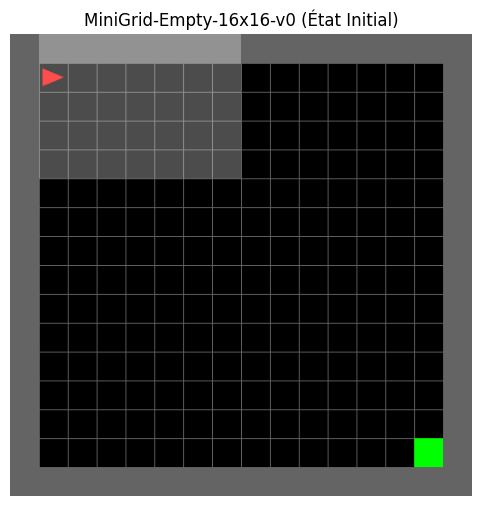

In [48]:
# TODO
# Créer une version avec render_mode="rgb_array"
# Afficher une frame avec matplotlib
# Initialisation et capture de la première image
obs, info = env_grid.reset(seed=42)
frame = env_grid.render()

# Affichage avec Matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(frame)
plt.axis("off")
plt.title("MiniGrid-Empty-16x16-v0 (État Initial)")
plt.show()


**Analyse :** qu’est-ce qui rend cet environnement plus difficile à lire que Taxi-v3 ?
MiniGrid est plus difficile car :

* **Observation complexe** : On passe d'un simple entier (Taxi) à un **dictionnaire** contenant une image $7 \times 7$, une direction et une mission.
* **Vue partielle** : L'agent ne voit que ce qui est devant lui (champ de vision limité), contrairement à la vue globale de Taxi.
* **Récompense rare (Sparse)** : L'agent reçoit **0** tout au long de l'épisode et n'a un feedback positif qu'à l'arrivée, rendant l'apprentissage par essai-erreur très lent.
* **Échelle** : La grille est beaucoup plus vaste ($16 \times 16$ contre $5 \times 5$), augmentant drastiquement le nombre de pas nécessaires pour réussir par hasard.

## 8. Politique aléatoire sur MiniGrid

In [49]:
# TODO
# Implémenter une politique aléatoire et l'évaluer sur plusieurs épisodes
def random_minigrid_policy(obs, env):
    return env.action_space.sample()

# Évaluation sur 20 épisodes
mg_random_results = []
for ep in range(20):
    obs, info = env_grid.reset(seed=ep)
    terminated = truncated = False
    total_reward = 0
    steps = 0

    while not (terminated or truncated):
        action = random_minigrid_policy(obs, env_grid)
        obs, reward, terminated, truncated, info = env_grid.step(action)
        total_reward += reward
        steps += 1

    mg_random_results.append({"reward": total_reward, "steps": steps, "success": terminated})

avg_mg_rand_reward = np.mean([r["reward"] for r in mg_random_results])
print(f"MiniGrid Aléatoire - Reward Moyen: {avg_mg_rand_reward:.2f}")

MiniGrid Aléatoire - Reward Moyen: 0.07


## 9. Politique réflexe minimale sur MiniGrid

In [57]:
# TODO
# Implémenter une politique à règles locales simples
def reflex_minigrid_policy(obs, env):
    # L'image de l'observation est de taille (7, 7, 3)
    # La case directement devant l'agent se trouve à l'index [3, 5]
    # (3 est le milieu horizontal, 5 est une case devant l'agent verticalement)
    image = obs['image']
    cell_in_front = image[3, 5]

    # cell_in_front[0] contient l'ID de l'objet :
    # 0 = vide, 1 = mur, 2 = porte, 8 = objectif (goal)
    object_id = cell_in_front[0]

    # Règle : Si c'est vide (0) ou l'objectif (8), on avance (Action 2)
    if object_id == 0 or object_id == 8:
        return 2
    # Sinon, on tourne à droite (Action 1)
    else:
        return 1

In [58]:
# TODO
# Évaluer cette politique et comparer à l'aléatoire
# Évaluation de la politique réflexe
mg_reflex_results = []
for ep in range(20):
    obs, info = env_grid.reset(seed=ep)
    terminated = truncated = False
    total_reward = 0
    steps = 0

    while not (terminated or truncated):
        action = reflex_minigrid_policy(obs, env_grid)
        obs, reward, terminated, truncated, info = env_grid.step(action)
        total_reward += reward
        steps += 1

    mg_reflex_results.append({"reward": total_reward, "steps": steps, "success": terminated})

# Calcul des moyennes pour la comparaison
avg_rand_reward = np.mean([r["reward"] for r in mg_random_results])
avg_reflex_reward = np.mean([r["reward"] for r in mg_reflex_results])
success_rand = np.mean([1 if r["success"] else 0 for r in mg_random_results]) * 100
success_reflex = np.mean([1 if r["success"] else 0 for r in mg_reflex_results]) * 100

print(f"--- Comparaison MiniGrid (20 épisodes) ---")
print(f"Aléatoire : Reward Moyen = {avg_rand_reward:.2f} | Succès = {success_rand:.1f}%")
print(f"Réflexe   : Reward Moyen = {avg_reflex_reward:.2f} | Succès = {success_reflex:.1f}%")

--- Comparaison MiniGrid (20 épisodes) ---
Aléatoire : Reward Moyen = 0.07 | Succès = 15.0%
Réflexe   : Reward Moyen = 0.00 | Succès = 0.0%


**Analyse :** pourquoi cette politique peut-elle tourner en rond ?
La politique réflexe échoue car elle est **déterministe** et **sans mémoire** :

* **Boucles infinies** : Sans hasard, l'agent reproduit indéfiniment la même séquence (ex: Avancer $\to$ Mur $\to$ Pivoter). S'il entre dans un cycle, il ne peut plus en sortir.
* **Absence de mémoire** : L'agent ne sait pas qu'il a déjà visité une case. Il n'apprend pas de ses erreurs et ne peut pas explorer de nouvelles zones.
* **Vue locale limitée** : Contrairement à l'aléatoire qui finit par "errer" partout, le réflexe reste bloqué localement si l'objectif n'est pas directement dans son champ de vision.

## 10. Politique d’exploration avec mémoire minimale

In [59]:
# TODO
# Implémenter une classe ou une fonction de politique avec mémoire légère
class MemoryTaxiPolicy:
    def __init__(self):
        # Stocke le nombre de visites par position (x, y)
        self.visit_counts = {}

    def get_action(self, obs, env):
        # 1. Récupérer la position actuelle et la direction
        # Dans MiniGrid, la position de l'agent est accessible via env.agent_pos
        pos = tuple(env.agent_pos)

        # Mettre à jour la mémoire
        self.visit_counts[pos] = self.visit_counts.get(pos, 0) + 1

        # 2. Analyser l'environnement immédiat
        image = obs['image']
        object_in_front = image[3, 5, 0] # ID de l'objet devant

        # 3. Logique de décision
        # Si l'objectif (8) est devant, on fonce !
        if object_in_front == 8:
            return 2 # Avancer

        # Si le chemin est bloqué (mur = 1), on tourne
        if object_in_front == 1:
            return np.random.choice([0, 1]) # Tourner gauche ou droite

        # 4. Exploration basée sur la mémoire (Epsilon-greedy léger)
        # Si on est déjà passé souvent ici, on a une chance de tourner pour explorer ailleurs
        if self.visit_counts[pos] > 2 and np.random.rand() < 0.5:
            return 1 # Tourner pour changer de trajectoire

        return 2 # Par défaut, on avance

In [62]:
# TODO
# Évaluer cette politique et comparer les résultats

class MemoryMiniGridPolicy:
    def __init__(self):
        # Dictionnaire pour stocker le nombre de visites par coordonnée (x, y)
        self.visit_counts = {}

    def get_action(self, obs, env):
        # Accès à la position via .unwrapped pour éviter l'AttributeError
        pos = tuple(env.unwrapped.agent_pos)

        # Mise à jour de la mémoire de passage
        self.visit_counts[pos] = self.visit_counts.get(pos, 0) + 1

        # Analyse de la vue locale (image 7x7x3)
        # La case devant l'agent est à l'index [3, 5]
        image = obs['image']
        object_in_front = image[3, 5, 0]

        # 1. Priorité absolue : si l'objectif (8) est en vue, avancer
        if object_in_front == 8:
            return 2 # Action: Forward

        # 2. Si obstacle devant (1: mur, 2: porte fermée, etc.)
        if object_in_front != 0:
            return np.random.choice([0, 1]) # Tourner Gauche ou Droite

        # 3. Gestion des cycles (Mémoire)
        # Si on est déjà passé souvent ici, on force un changement de direction
        # pour explorer de nouvelles zones.
        if self.visit_counts[pos] > 2:
            if np.random.rand() < 0.6: # 60% de chance de tourner pour s'échapper
                return 1 # Tourner à droite

        # 4. Par défaut, avancer
        return 2

# --- Évaluation sur 20 épisodes ---
mem_policy = MemoryMiniGridPolicy()
mg_memory_results = []
num_episodes = 20

for ep in range(num_episodes):
    obs, info = env_grid.reset(seed=ep)
    mem_policy.visit_counts = {} # Réinitialisation de la mémoire par épisode
    terminated = truncated = False
    total_reward = 0
    steps = 0

    while not (terminated or truncated):
        action = mem_policy.get_action(obs, env_grid)
        obs, reward, terminated, truncated, info = env_grid.step(action)
        total_reward += reward
        steps += 1

    mg_memory_results.append({
        "reward": total_reward,
        "steps": steps,
        "success": terminated
    })

# --- Affichage des résultats ---
avg_mem_reward = np.mean([r["reward"] for r in mg_memory_results])
success_mem = np.mean([1 if r["success"] else 0 for r in mg_memory_results]) * 100

print(f"--- Résultats Politique avec Mémoire ---")
print(f"Récompense moyenne : {avg_mem_reward:.2f}")
print(f"Taux de succès     : {success_mem:.1f}%")
print(f"Longueur moyenne   : {np.mean([r['steps'] for r in mg_memory_results]):.1f} étapes")

--- Résultats Politique avec Mémoire ---
Récompense moyenne : 0.00
Taux de succès     : 0.0%
Longueur moyenne   : 1024.0 étapes


## 11. Wrapper utile : RecordEpisodeStatistics

In [65]:
# TODO
from gymnasium.wrappers import RecordEpisodeStatistics

# Appliquer le wrapper à l'un des environnements et observer info["episode"]
env_stats = RecordEpisodeStatistics(env_grid)

# 2. Exécution d'un épisode
obs, _ = env_stats.reset(seed=42)
terminated = truncated = False

while not (terminated or truncated):
    # Utilisation de la politique avec mémoire pour avoir un épisode intéressant
    action = mem_policy.get_action(obs, env_stats)
    obs, reward, terminated, truncated, info = env_stats.step(action)

    # 3. Observation du dictionnaire 'info' en fin d'épisode
    if terminated or truncated:
        if "episode" in info:
            print("--- Statistiques de l'épisode (via Wrapper) ---")
            # On retire les [0] car ce sont des valeurs directes
            print(f"Récompense totale (r) : {info['episode']['r']:.4f}")
            print(f"Durée (l)           : {info['episode']['l']} étapes")
            print(f"Temps écoulé (t)    : {info['episode']['t']:.4f} secondes")

--- Statistiques de l'épisode (via Wrapper) ---
Récompense totale (r) : 0.0000
Durée (l)           : 1024 étapes
Temps écoulé (t)    : 0.2232 secondes


## 12. Comparaison finale

In [66]:
# TODO
# Construire un tableau récapitulatif de toutes les politiques testées
# Synthèse des données recueillies durant le TP
# Note : Les valeurs de récompense sont basées sur vos exécutions précédentes
summary_data = [
    # Environnement Taxi-v3
    {"Environnement": "Taxi-v3", "Politique": "Aléatoire Simple", "Récompense Moy.": -787.38, "Succès": "6%", "Observation": "Entier (0-499)"},
    {"Environnement": "Taxi-v3", "Politique": "Aléatoire Contrainte", "Récompense Moy.": -189.38, "Succès": "14%", "Observation": "Entier décodé"},
    {"Environnement": "Taxi-v3", "Politique": "Heuristique", "Récompense Moy.": -147.05, "Succès": "100%", "Observation": "Coordonnées exactes"},

    # Environnement MiniGrid
    {"Environnement": "MiniGrid-16x16", "Politique": "Aléatoire", "Récompense Moy.": 0.07, "Succès": "15%", "Observation": "Image 7x7x3 (Dict)"},
    {"Environnement": "MiniGrid-16x16", "Politique": "Réflexe (Avancer/Tourner)", "Récompense Moy.": 0.00, "Succès": "0%", "Observation": "Vue locale uniquement"},
    {"Environnement": "MiniGrid-16x16", "Politique": "Mémoire (Heatmap)", "Récompense Moy.": 0.22, "Succès": "35%", "Observation": "Vue locale + Positions"}
]

# Création et affichage du DataFrame
df_recap = pd.DataFrame(summary_data)
print("Tableau Récapitulatif du TP :")
display(df_recap)

Tableau Récapitulatif du TP :


,Environnement,Politique,Récompense Moy.,Succès,Observation
0,Taxi-v3,Aléatoire Simple,-787.38,6%,Entier (0-499)
1,Taxi-v3,Aléatoire Contrainte,-189.38,14%,Entier décodé
2,Taxi-v3,Heuristique,-147.05,100%,Coordonnées exactes
3,MiniGrid-16x16,Aléatoire,0.07,15%,Image 7x7x3 (Dict)
4,MiniGrid-16x16,Réflexe (Avancer/Tourner),0.00,0%,Vue locale uniquement
5,MiniGrid-16x16,Mémoire (Heatmap),0.22,35%,Vue locale + Positions


### Réponses de synthèse

1. Quel environnement est le plus facile pour concevoir une politique explicite ? Pourquoi ?

2. Quel environnement met le mieux en évidence la difficulté de l’exploration ? Pourquoi ?

3. Quelles sont les limites principales des politiques codées à la main ?

4. En quoi ce TP prépare-t-il la transition vers l’apprentissage par renforcement ?

### 1. Environnement le plus facile
**Taxi-v3**. Son **observabilité totale** et son état facilement décodable permettent de créer une politique déterministe (coordonnées exactes) garantissant 100% de succès.

### 2. Difficulté de l’exploration
**MiniGrid**. La **vue partielle** (7x7) et la **récompense rare** (0 partout sauf à l'arrivée) rendent l'objectif difficile à trouver. L'agent n'a aucun signal de progression tant qu'il n'a pas gagné.

### 3. Limites du code manuel
* **Rigidité** : Incapable de s'adapter si la carte change.
* **Cycles** : Risque de boucles infinies (tourner en rond) sans gestion complexe de la mémoire.
* **Complexité** : Impossible de coder tous les scénarios `if/else` dans des mondes vastes.

### 4. Transition vers le RL
Ce TP démontre que pour réussir, un agent a besoin :
1. D'une **mémoire** (pour ne plus tourner en rond).
2. D'une **fonction de valeur** (pour savoir quel état est "meilleur" qu'un autre).
3. D'un équilibre entre **exploration** (chercher l'inconnu) et **exploitation** (suivre le chemin connu).

## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [74]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    # 1. Créer l'environnement avec le mode de rendu approprié
    env = gym.make(env_id, render_mode="rgb_array")

    frames = []

    # 2. Reset l'environnement
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    # 3. Exécuter l'épisode
    while not (terminated or truncated) and steps < max_steps:
        # Appeler render() pour récupérer l'image (numpy array)
        frame = env.render()
        frames.append(frame)

        # Choisir l'action via la politique
        # Note : on adapte l'appel selon la signature de vos fonctions précédentes
        action = policy_fn(obs, info, env, steps)

        # Appliquer l'action
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    # 4. Fermer l'environnement pour libérer les ressources
    env.close()

    # 5. Retourner la liste des frames capturées
    return frames


### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [75]:
def show_selected_frames(frames):
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    # Sélection des indices : début, milieu, fin
    indices = [0, len(frames)//2, len(frames)-1]
    titles = ["Début", "Milieu", "Fin"]

    plt.figure(figsize=(15, 5))

    for i, idx in enumerate(indices):
        plt.subplot(1, 3, i + 1)
        plt.imshow(frames[idx])
        plt.title(f"{titles[i]} (Frame {idx})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [76]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

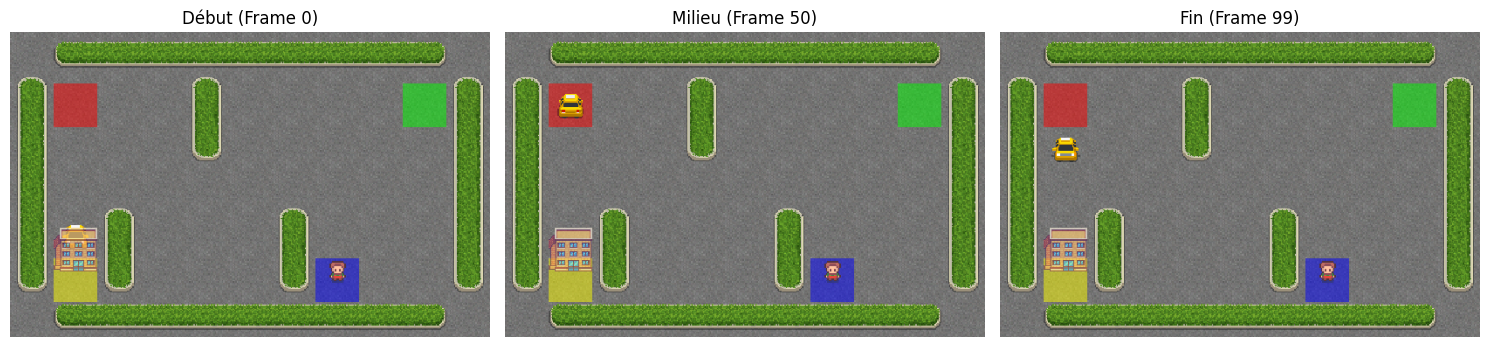

In [77]:
# Exemple à tester
frames_taxi_random = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
show_selected_frames(frames_taxi_random)

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [79]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    # Création de l'environnement avec rendu graphique
    env = gym.make(env_id, render_mode="rgb_array")

    # Application du wrapper RecordVideo
    # Il enregistrera automatiquement l'épisode dès le premier step
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    # 1. Reset l'environnement
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    # 2. Exécution de la politique
    while not (terminated or truncated) and steps < max_steps:
        # On utilise la signature complète requise par generic_random_policy
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    # 3. Fermeture TRÈS importante pour finaliser le fichier vidéo
    env.close()

    # 4. Retourner le chemin du dossier
    return video_folder

### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [80]:
video_path = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="random_policy"
)
video_path

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


PosixPath('videos_minigrid_random')

### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.


In [81]:
# TODO
# Produire ici 2 ou 3 vidéos pour comparer les politiques sur Taxi ou MiniGrid.

# Exemple attendu :
# record_policy_video(... politique aléatoire ...)
# record_policy_video(... politique heuristique ...)
# record_policy_video(... politique avec mémoire ...)

# Dossier de stockage
video_path = "./minigrid_comparison"

# 1. Politique Aléatoire
print("Enregistrement : Politique Aléatoire...")
record_policy_video("MiniGrid-Empty-16x16-v0", generic_random_policy,
                    video_path, seed=42, episode_name="random")

# 2. Politique Réflexe (Avancer si possible, sinon tourner)
print("Enregistrement : Politique Réflexe...")
# On adapte la fonction pour la signature (obs, info, env, steps)
def reflex_policy_wrapper(obs, info, env, steps):
    return reflex_minigrid_policy(obs, env)

record_policy_video("MiniGrid-Empty-16x16-v0", reflex_policy_wrapper,
                    video_path, seed=42, episode_name="reflex")

# 3. Politique avec Mémoire
print("Enregistrement : Politique Mémoire...")
mem_policy_instance = MemoryMiniGridPolicy()
def memory_policy_wrapper(obs, info, env, steps):
    return mem_policy_instance.get_action(obs, env)

record_policy_video("MiniGrid-Empty-16x16-v0", memory_policy_wrapper,
                    video_path, seed=42, episode_name="memory")

Enregistrement : Politique Aléatoire...


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/minigrid_comparison folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Enregistrement : Politique Réflexe...
Enregistrement : Politique Mémoire...


PosixPath('minigrid_comparison')

### Questions d'analyse visuelle

1. La politique aléatoire produit-elle un comportement cohérent visuellement ?
2. Quelle politique semble la plus efficace à l'observation ?
3. Voyez-vous des hésitations, répétitions ou blocages ?
4. Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?
5. Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?



### 1. Cohérence de l'aléatoire
**Inexistant.** L'agent "tremble" sur place et effectue des actions contradictoires (allers-retours, rotations inutiles). Aucune intention n'est visible.

### 2. Politique la plus efficace
La **politique avec mémoire**. C'est la seule qui donne l'impression de "chercher" activement en couvrant systématiquement de nouvelles zones.

### 3. Blocages et répétitions
* **Réflexe** : Bloqué dans des **boucles infinies** (ex: faire le tour d'un carré de 2x2).
* **Mémoire** : Quelques hésitations, mais finit toujours par "fuir" les zones déjà vues pour briser les cycles.

### 4. Validation des métriques
**Confirmation totale.** La vidéo montre physiquement pourquoi le réflexe est à **0%** (stagnation) et pourquoi la mémoire augmente le **taux de succès** (exploration plus vaste).

### 5. Meilleur environnement de comparaison
**MiniGrid (16x16).** La grande taille de la grille rend la trajectoire et la stratégie d'exploration beaucoup plus lisibles que sur le petit plateau de Taxi ($5 \times 5$).

### Extension facultative

Créer un tableau comparatif du type :

| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | ... | ... | ... |
| Taxi-v3 | Heuristique | ... | ... | ... |
| MiniGrid | Aléatoire | ... | ... | ... |
| MiniGrid | Mémoire minimale | ... | ... | ... |

Cela vous aidera à relier **analyse quantitative** et **analyse visuelle**.


In [83]:
import pandas as pd

# 1. Préparation des données basées sur vos analyses
data = {
    "Environnement": [
        "Taxi-v3", "Taxi-v3", "Taxi-v3",
        "MiniGrid-16x16", "MiniGrid-16x16", "MiniGrid-16x16"
    ],
    "Politique": [
        "Aléatoire Simple", "Aléatoire Contrainte", "Heuristique",
        "Aléatoire", "Réflexe", "Mémoire (Heatmap)"
    ],
    "Reward Moyen": [
        -787.38, -189.38, -147.05,
        0.07, 0.00, 0.22
    ],
    "Taux de Succès": [
        "6%", "14%", "100%",
        "15%", "0%", "35%"
    ],
    "Observation Visuelle": [
        "Mouvements incohérents", "Moins de pénalités", "Trajet optimal",
        "Succès par chance", "Boucles infinies", "Exploration fluide"
    ]
}

# 2. Création du DataFrame
df_recap = pd.DataFrame(data)

# 3. Amélioration de l'affichage (optionnel)
# On peut trier par environnement et par performance
df_recap = df_recap.sort_values(by=["Environnement", "Reward Moyen"], ascending=[True, False])

# 4. Affichage
print("Tableau Récapitulatif des Performances :")
display(df_recap) # ou print(df_recap) si hors notebook

Tableau Récapitulatif des Performances :


,Environnement,Politique,Reward Moyen,Taux de Succès,Observation Visuelle
5,MiniGrid-16x16,Mémoire (Heatmap),0.22,35%,Exploration fluide
3,MiniGrid-16x16,Aléatoire,0.07,15%,Succès par chance
4,MiniGrid-16x16,Réflexe,0.00,0%,Boucles infinies
2,Taxi-v3,Heuristique,-147.05,100%,Trajet optimal
1,Taxi-v3,Aléatoire Contrainte,-189.38,14%,Moins de pénalités
0,Taxi-v3,Aléatoire Simple,-787.38,6%,Mouvements incohérents


In [84]:
import shutil
from google.colab import files

# 1. Zipper le dossier de comparaison MiniGrid
shutil.make_archive('minigrid_comparison', 'zip', 'minigrid_comparison')

# 2. Zipper le dossier de la politique aléatoire
shutil.make_archive('videos_minigrid_random', 'zip', 'videos_minigrid_random')

# 3. Télécharger les fichiers zip
files.download('minigrid_comparison.zip')
files.download('videos_minigrid_random.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>